# Simulations Analysis

Analysis of simulation outputs and comparison with empirical data.

**Inputs required:**
- `data/all_observations.csv` — from `01_video_processing.ipynb`
- `data/derived/response_videos.csv` — from `02_prepare_model_input.ipynb`
- `outputs/simulations/GMM_3D/` — from `scripts/simulations/07_run_experiment.R`
- `outputs/simulations/Real_3D/` — from `scripts/simulations/07_run_experiment.R`

## Import libraries

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.genmod.families import Binomial
from scipy.stats import pearsonr

## Set color palette & styles

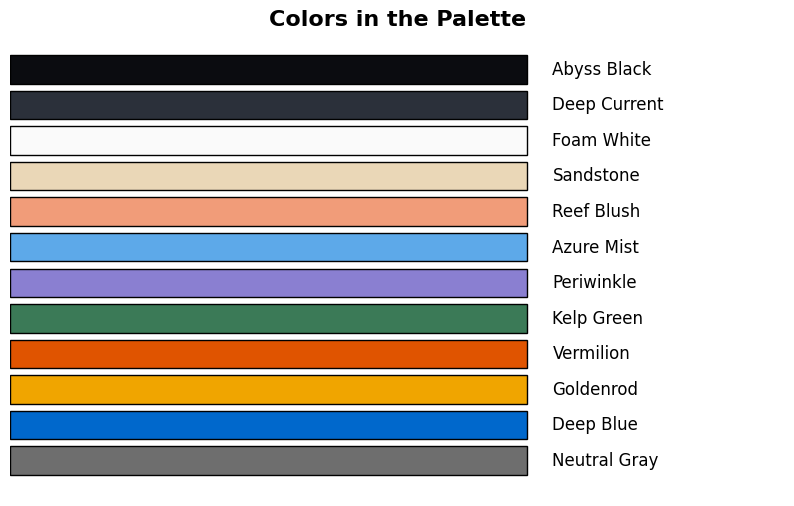

In [44]:
# ================================
# Color map for Project 2
# ================================

colors_figures_p2 = {
    # --- Core model colors (slightly more saturated for print) ---
    "Neutral Gray": "#6E6E6E",  # Di – neutral gray
    "Deep Blue":    "#0068CC",  # DiT – vivid deep blue
    "Goldenrod":    "#F0A500",  # DiTDe – warm bright gold
    "Vermilion":    "#E05400",  # DiTDeS – lively coral orange-red

    # --- Supporting tones ---
    "Kelp Green":   "#3B7A57",
    "Periwinkle":   "#8A7FD1",
    "Azure Mist":   "#5DA9E9",
    "Reef Blush":   "#F19C79",
    "Sandstone":    "#EAD7B7",
    "Foam White":   "#FAFAFA",
    "Deep Current": "#2B303A",
    "Abyss Black":  "#0B0C10",
}


# Create a bar chart to display the colors
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each color with its name
for i, (name, color) in enumerate(colors_figures_p2.items()):
    ax.barh(i, 1, color=color, edgecolor="black")
    ax.text(1.05, i, name, va='center', fontsize=12)

    # Adjust the appearance of the plot
    ax.set_xlim(0, 1.5)
    ax.set_ylim(-1, len(colors_figures_p2))
    ax.axis('off')
    ax.set_title("Colors in the Palette", fontsize=16, weight='bold')

In [45]:
import matplotlib as mpl

def set_p2_style(base_fontsize=11):
    mpl.rcParams.update({
        # fonts & sizes
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,
        "axes.titlesize": base_fontsize + 4,
        "axes.labelsize": base_fontsize + 2,
        "legend.fontsize": base_fontsize + 2,
        "xtick.labelsize": base_fontsize,
        "ytick.labelsize": base_fontsize,

        # lines
        "lines.linewidth": 2.6,
        "lines.markersize": 4,

        # axes
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.0,
        "axes.grid": True, 

        # grid
        "grid.linestyle": "-",
        "grid.alpha": 0.08,

        # legend (clean by default)
        "legend.frameon": False,
        "legend.framealpha": 0.95,
        "legend.facecolor": "white",
        "legend.edgecolor": "#dddddd",
        "legend.borderpad": 0.4,
    })


In [46]:
MODEL_COLORS = {
    "Di":     colors_figures_p2["Neutral Gray"],
    "DiT":    colors_figures_p2["Deep Blue"],
    "DiTDe":  colors_figures_p2["Goldenrod"],
    "DiTDeS": colors_figures_p2["Vermilion"],
}

NETWORK_COLORS = {
    "Real":   colors_figures_p2["Kelp Green"],
    "GMM":    colors_figures_p2["Azure Mist"]
}

NETWORK_LINESTYLES = {
    "Real": "--",
    "GMM":  "-",
}
NETWORK_RIBBON_ALPHA = {
    "Real": 0.08,
    "GMM":  0.08,
}

## Load dataset & simulation results

In [47]:
from pathlib import Path
path = Path('..')

Summaries      = pd.read_csv(path / 'data' / 'all_observations.csv')
ResponseVideos = pd.read_csv(path / 'data' / 'derived' / 'response_videos.csv')

# First responders — filtered from full dataset for speed analysis
FR_Information = Summaries[Summaries['Response_Category'] == 'FR'].copy()

REAL_PATH = path / 'outputs' / 'simulations' / 'Real_3D'
GMM_PATH  = path / 'outputs' / 'simulations' / 'GMM_3D'


In [48]:
Real_lognormal = pd.read_csv(REAL_PATH / 'Experimental_Simulations_3D_REAL_Results_20260224-133717_NFR1_FRspdlognormal_dec0p0551_tmax400.csv')
GMM_lognormal = pd.read_csv(GMM_PATH / 'Experimental_Simulations_3D_GMM_Results_20260224-113440_NFR1_FRspdlognormal_dec0p0551_tmax400.csv')

In [49]:
Real_binary = pd.read_csv(REAL_PATH / 'Experimental_Simulations_3D_REAL_Results_20260224-134047_NFR1_FRspdbinary_dec0p0551_tmax400.csv', low_memory=False)
GMM_binary = pd.read_csv(GMM_PATH / 'Experimental_Simulations_3D_GMM_Results_20260224-113618_NFR1_FRspdbinary_dec0p0551_tmax400.csv', low_memory=False) 

In [50]:
Neighbour_Inputs_Summary = pd.read_csv(GMM_PATH / 'Diagnostics/TRACEINPUTS_Q3_20260224-113835_DiTDeS_NFR1_gmm_dec0.0551/SUMMARY_ALL.csv')
Neighbour_Inputs_Trace = pd.read_csv(GMM_PATH / 'Diagnostics/TRACEINPUTS_Q3_20260224-113835_DiTDeS_NFR1_gmm_dec0.0551/TRACE_ALL.csv')
Neighbour_Inputs_Contribution = pd.read_csv(GMM_PATH / 'Diagnostics/TRACEINPUTS_Q3_20260224-113835_DiTDeS_NFR1_gmm_dec0.0551/CONTRIB_TOPK_ALL.csv')

In [51]:
NoSpeedDecay = pd.read_csv(GMM_PATH / 'Experimental_Simulations_3D_GMM_Results_20260217-145633_NFR1_FRspdbinary_dec0p0000_tmax400.csv', low_memory=False)
NSD_Neighbour_Inputs_Summary = pd.read_csv(GMM_PATH / 'Diagnostics/TRACEINPUTS_Q3_20260217-232311_DiTDeS_NFR1_gmm/SUMMARY_ALL.csv')
NSD_Neighbour_Inputs_Trace = pd.read_csv(GMM_PATH / 'Diagnostics/TRACEINPUTS_Q3_20260217-232311_DiTDeS_NFR1_gmm/TRACE_ALL.csv')
NSD_Neighbour_Inputs_Contribution = pd.read_csv(GMM_PATH / 'Diagnostics/TRACEINPUTS_Q3_20260217-232311_DiTDeS_NFR1_gmm/CONTRIB_TOPK_ALL.csv')

## Answers to questions

### Q0. Do simulations on empirical and GMM-generated geometries produce qualitatively similar cascade patterns?

In [52]:
# -------------------------
# 1) Combine + harmonize
# -------------------------
real = Real_lognormal.copy()
gmm  = GMM_lognormal.copy()

real["Geometry"] = "Real"
gmm["Geometry"]  = "GMM"

df_lognormal = pd.concat([real, gmm], ignore_index=True)

# Prefer N_Fish if present; fall back to Group_Size_Used then Group_Size_Requested
if "N_Fish" in df_lognormal.columns:
    df_lognormal["GroupSize"] = pd.to_numeric(df_lognormal["N_Fish"], errors="coerce")
elif "Group_Size_Used" in df_lognormal.columns:
    df_lognormal["GroupSize"] = pd.to_numeric(df_lognormal["Group_Size_Used"], errors="coerce")
else:
    df_lognormal["GroupSize"] = pd.to_numeric(df_lognormal["Group_Size_Requested"], errors="coerce")

# Cascade fraction
df_lognormal["N_Startles"] = pd.to_numeric(df_lognormal["N_Startles"], errors="coerce")
df_lognormal["CascadeFrac"] = ((df_lognormal["N_Startles"] - df_lognormal["N_FRs"]) /(df_lognormal["GroupSize"] - df_lognormal["N_FRs"]))

df_lognormal.loc[df_lognormal["GroupSize"] == df_lognormal["N_FRs"], "CascadeFrac"] = np.nan

# Clean
df_lognormal["Model"] = df_lognormal["Model"].astype(str)
df_lognormal = df_lognormal.dropna(subset=["Geometry", "Model", "GroupSize", "CascadeFrac"])
df_lognormal = df_lognormal[(df_lognormal["CascadeFrac"] >= 0) & (df_lognormal["CascadeFrac"] <= 1)]

# Optional: drop rows that have an error flag
if "Error" in df_lognormal.columns:
    df_lognormal = df_lognormal[df_lognormal["Error"].isna()]

In [53]:
# -------------------------
# 2) Summarise: median + IQR
# -------------------------
def q25(x): return np.percentile(x, 25)
def q75(x): return np.percentile(x, 75)

summ = (
    df_lognormal.groupby(["Geometry", "Model", "GroupSize"])["CascadeFrac"]
      .agg(median="median", q25=q25, q75=q75, n="count")
      .reset_index()
      .sort_values(["Model", "Geometry", "GroupSize"])
)

In [54]:
# -------------------------
# 3) Rolling smoothing helper
# -------------------------
def smooth_by_groupsize(df, window=5):
    """
    Apply rolling median smoothing over GroupSize.
    Window is in number of group-size points (not absolute size).
    """
    out = []
    for (geom, model), sub in df.groupby(["Geometry", "Model"]):
        sub = sub.sort_values("GroupSize").copy()

        sub["median_smooth"] = (
            sub["median"]
            .rolling(window=window, center=True, min_periods=1)
            .median()
        )

        sub["q25_smooth"] = (
            sub["q25"]
            .rolling(window=window, center=True, min_periods=1)
            .median()
        )

        sub["q75_smooth"] = (
            sub["q75"]
            .rolling(window=window, center=True, min_periods=1)
            .median()
        )

        out.append(sub)

    return pd.concat(out, ignore_index=True)

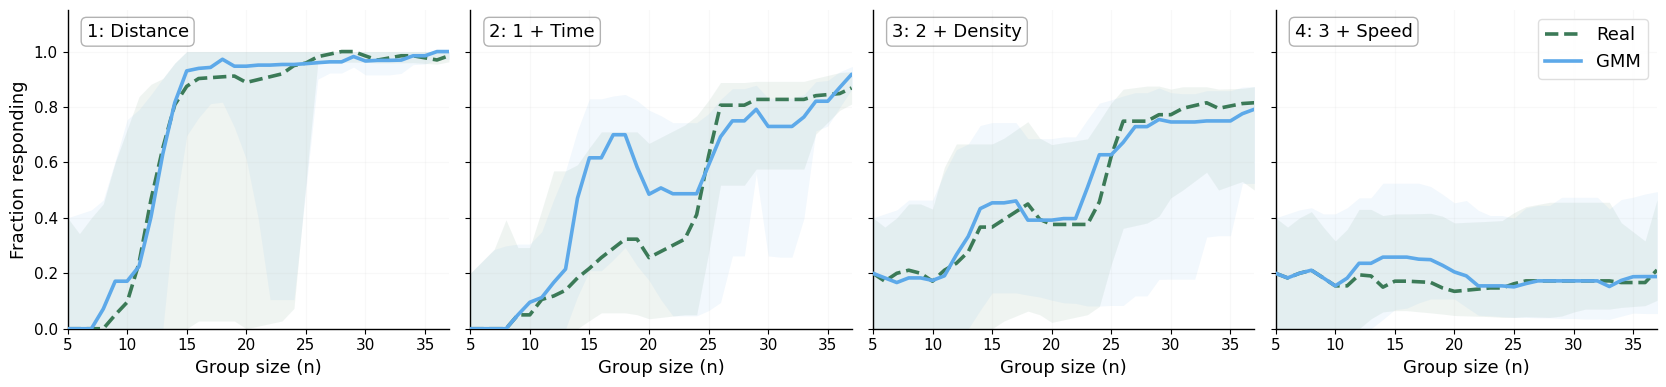

In [55]:
# 0) Apply global style ONCE
set_p2_style(base_fontsize=11)

# -------------------------
# 4) Plot: one panel per model
# -------------------------
model_order = ["Di", "DiT", "DiTDe", "DiTDeS"]
models = [m for m in model_order if m in summ["Model"].unique()] + \
         [m for m in summ["Model"].unique() if m not in model_order]

summ_smooth = smooth_by_groupsize(summ, window=6)
model_names = {
    "Di": "1: Distance",
    "DiT": "2: 1 + Time",
    "DiTDe": "3: 2 + Density",
    "DiTDeS": "4: 3 + Speed"
}

fig, axes = plt.subplots(
    nrows=1, ncols=len(models),
    figsize=(4.2 * len(models), 4),
    sharey=True
)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    # Let rcParams control grid styling (don't override alpha here)
    ax.grid(True)  # optional; rcParams already has axes.grid=True

    sub_m = summ_smooth[summ_smooth["Model"] == model]

    for geom in ["Real", "GMM"]:
        sub = sub_m[sub_m["Geometry"] == geom].sort_values("GroupSize")
        if sub.empty:
            continue

        # Line: let rcParams set linewidth; keep only color/linestyle/label
        ax.plot(
            sub["GroupSize"],
            sub["median_smooth"],
            color=NETWORK_COLORS[geom],
            linestyle=NETWORK_LINESTYLES[geom],
            label=geom,
            zorder=3
        )

        # Ribbon: keep alpha as your design choice; everything else style-controlled
        ax.fill_between(
            sub["GroupSize"],
            sub["q25_smooth"],
            sub["q75_smooth"],
            color=NETWORK_COLORS[geom],
            alpha=NETWORK_RIBBON_ALPHA[geom],
            linewidth=0,
            zorder=1
        )

    ax.set_xlabel("Group size (n)")
    ax.set_ylim(0, 1.15)
    ax.set_xlim(5, 37)

    # Panel label: let rcParams control fontsize unless you *need* it larger
    ax.text(
        0.05, 0.96, model_names.get(model, model),
        ha="left", va="top",
        transform=ax.transAxes, fontsize = plt.rcParams["axes.titlesize"] - 2,
        bbox=dict(facecolor="white", alpha=0.3, edgecolor="black", pad=0.3, boxstyle="round")
    )

axes[0].set_ylabel("Fraction responding")

# Legend: let rcParams control font size/frame unless you need an exception
axes[3].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


In [56]:
# ---- column names (edit if needed) ----
MODEL_COL = "Model"
GEOM_COL  = "Geometry"
GS_COL    = "N_Fish"
VAL_COL   = "N_Startles"  # or "CascadeFrac" if you want to compare that instead

# ---- 1) average over replicates first ----
df_mean = (
    df_lognormal
    .groupby([MODEL_COL, GEOM_COL, GS_COL], as_index=False)[VAL_COL]
    .mean()
)

# ---- 2) pivot Real vs GMM ----
df_wide = (
    df_mean
    .pivot_table(
        index=[MODEL_COL, GS_COL],
        columns=GEOM_COL,
        values=VAL_COL
    )
    .reset_index()
    .dropna(subset=["Real", "GMM"])
)

# ---- 3) similarity metrics per model ----
rows = []

for model, sub in df_wide.groupby(MODEL_COL):
    diff = sub["Real"] - sub["GMM"]

    mad  = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    r, _ = pearsonr(sub["Real"], sub["GMM"])

    rows.append({
        "Model": model,
        "MAD (|Real − GMM|)": mad,
        "RMSE": rmse,
        "Pearson r": r,
        "n_group_sizes": len(sub)
    })

similarity_table = pd.DataFrame(rows)

similarity_table.round(3)


,Model,MAD (|Real − GMM|),RMSE,Pearson r,n_group_sizes
0,Di,1.457,2.038,0.981,27
1,DiT,1.640,2.336,0.969,27
2,DiTDe,1.345,2.358,0.959,27
3,DiTDeS,0.869,1.548,0.907,27


### Q1: Is the fitted individual decision rule sufficient to reproduce the group-size effect on cascades?

- For this, the GMM networks are used

#### Q1a: Plot the group-level patterns of the simulations

In [57]:
# df_emp must contain: GroupSize (or Group_Size) and Fraction_Responders
# Rename if needed so it matches the sim column name:
df_emp_plot = ResponseVideos.rename(columns={"Group_Size": "GroupSize"}).copy()
df_emp_plot["Fraction_Responders"] = (df_emp_plot["Nr_Responders"] - df_emp_plot['Nr_FR']) / (df_emp_plot["GroupSize"] - df_emp_plot["Nr_FR"])

emp_summ = (
    df_emp_plot
    .groupby("GroupSize", as_index=False)["Fraction_Responders"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n="size"
    )
)

# Add columns so it can pass through the same smoother
emp_summ["Model"] = "Empirical"
emp_summ["Geometry"] = "Empirical"


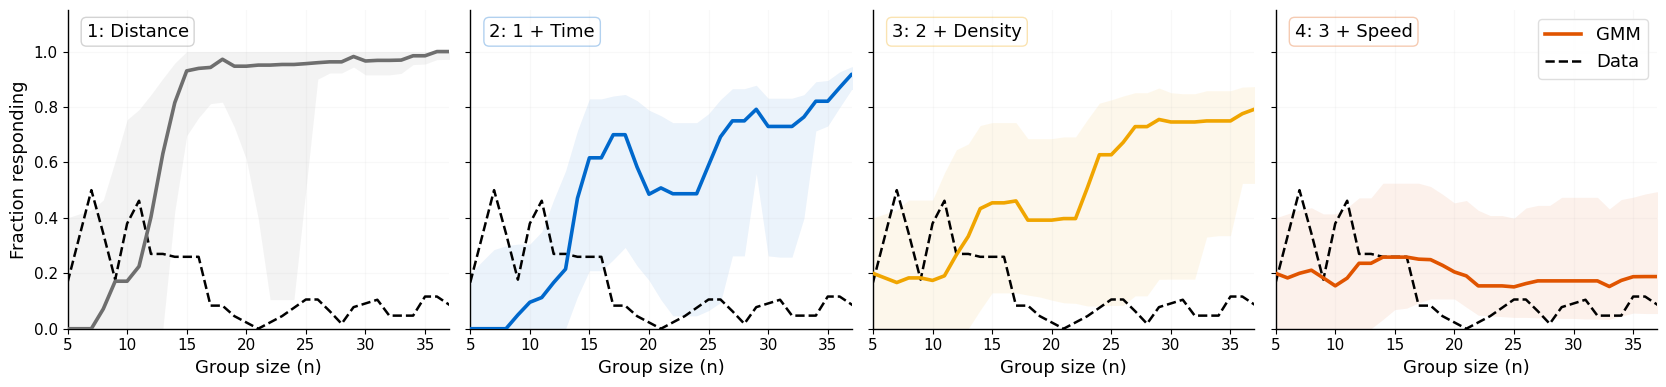

In [58]:
# -------------------------
# 4) Plot: one panel per model
# -------------------------
model_order = ["Di", "DiT", "DiTDe", "DiTDeS"]
models = [m for m in model_order if m in summ["Model"].unique()] + \
         [m for m in summ["Model"].unique() if m not in model_order]

summ_smooth = smooth_by_groupsize(summ, window=6)
emp_summ_smooth = smooth_by_groupsize(emp_summ, window=6)

model_names = {
    "Di": "1: Distance",
    "DiT": "2: 1 + Time",
    "DiTDe": "3: 2 + Density",
    "DiTDeS": "4: 3 + Speed"
}

fig, axes = plt.subplots(
    nrows=1, ncols=len(models),
    figsize=(4.2 * len(models), 4),
    sharey=True
)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    # Let rcParams control grid styling (don't override alpha here)
    ax.grid(True)  # optional; rcParams already has axes.grid=True

    sub_m = summ_smooth[summ_smooth["Model"] == model]

    for geom in ["GMM"]:
        sub = sub_m[sub_m["Geometry"] == geom].sort_values("GroupSize")
        if sub.empty:
            continue

        # Line: let rcParams set linewidth; keep only color/linestyle/label
        ax.plot(
            sub["GroupSize"],
            sub["median_smooth"],
            color=MODEL_COLORS[model],
            linestyle=NETWORK_LINESTYLES[geom],
            label=geom,
            zorder=3
        )

        # Ribbon: keep alpha as your design choice; everything else style-controlled
        ax.fill_between(
            sub["GroupSize"],
            sub["q25_smooth"],
            sub["q75_smooth"],
            color=MODEL_COLORS[model],
            alpha=NETWORK_RIBBON_ALPHA[geom],
            linewidth=0,
            zorder=1
        )

        emp_sub = emp_summ_smooth.sort_values("GroupSize")

        # Optional: empirical ribbon (keep very light, or remove entirely)
        #ax.fill_between(
        #    emp_sub["GroupSize"],
        #    emp_sub["q25_smooth"],
        #    emp_sub["q75_smooth"],
        #    color="black",
        #    alpha=0.08,
        #    linewidth=0,
        #    zorder=0
        #)

        ax.plot(
            emp_sub["GroupSize"],
            emp_sub["median_smooth"],
            linestyle="--",
            linewidth=1.8,
            color="black",
            label="Data"  # label once via legend handling (see below)
        )

    ax.set_xlabel("Group size (n)")
    ax.set_ylim(0, 1.15)
    ax.set_xlim(5, 37)

    # Panel label: let rcParams control fontsize unless you *need* it larger
    ax.text(
        0.05, 0.96, model_names.get(model, model),
        ha="left", va="top",
        transform=ax.transAxes, fontsize = plt.rcParams["axes.titlesize"] - 2,
        bbox=dict(facecolor="white", alpha=0.3, edgecolor=MODEL_COLORS[model], pad=0.3, boxstyle="round")
    )

axes[0].set_ylabel("Fraction responding")

# Legend: let rcParams control font size/frame unless you need an exception
axes[3].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

#### Q1b: Calculate MAD & RMSE for each simulation

In [59]:
GS = "Group_Size"

# --- REAL: make cascade fraction ---
df_real2 = ResponseVideos.copy()
if "CascadeFraction" not in df_real2.columns:
    df_real2["CascadeFraction"] = (df_real2["Nr_Responders"] - df_real2['Nr_FR']) / (df_real2[GS] - df_real2['Nr_FR']) 

df_real2["Source"] = "Data"
df_real2["Model"]  = "Data"   # makes faceting easier later

# --- SIM: make cascade fraction ---
df_sim2 = GMM_lognormal.copy()
if "CascadeFraction" not in df_sim2.columns:
    df_sim2["CascadeFraction"] = df_sim2["N_Startles"] / df_sim2['N_Fish']
if "Group_Size" not in df_sim2.columns:
    df_sim2["Group_Size"] = df_sim2["N_Fish"]

df_sim2["Source"] = "Sim"

# Keep only GMM sims if needed
# df_sim2 = df_sim2[df_sim2["NetworkType"].eq("GMM")].copy()


In [60]:
# group-size overlap
sizes_real = set(df_real2[GS].unique())
sizes_sim  = set(df_sim2[GS].unique())
common_sizes = sorted(sizes_real.intersection(sizes_sim))

df_real3 = df_real2[df_real2[GS].isin(common_sizes)].copy()
df_sim3  = df_sim2[df_sim2[GS].isin(common_sizes)].copy()

# Mean curve for data
curve_real = (df_real3.groupby(GS, as_index=False)["CascadeFraction"]
              .agg(mean="mean", n="size"))

# Mean curve for sims, per Model
curve_sim = (df_sim3.groupby(["Model", GS], as_index=False)["CascadeFraction"]
             .agg(mean="mean", n="size"))


In [61]:
out = []
for model, sub in curve_sim.groupby("Model"):
    merged = sub.merge(curve_real[[GS, "mean"]], on=GS, suffixes=("_sim", "_data"))
    diff = merged["mean_sim"] - merged["mean_data"]
    out.append({
        "Model": model,
        "MAD": float(np.mean(np.abs(diff))),
        "RMSE": float(np.sqrt(np.mean(diff**2))),
        "n_group_sizes": merged.shape[0],
    })

match_table = pd.DataFrame(out).sort_values("RMSE")
match_table.round(3)


,Model,MAD,RMSE,n_group_sizes
3,DiTDeS,0.228,0.282,28
2,DiTDe,0.335,0.393,28
1,DiT,0.389,0.466,28
0,Di,0.480,0.564,28


### Q2: How does response speed shape the propagation of cascades?

In [62]:
# -------------------------
# CONFIG — adjust if needed
# -------------------------
DF = GMM_binary
DF["AdditionalResp"] = (DF["N_Startles"] - DF["N_FRs"])

MODEL_COL = "Model"
GEOM_COL  = "Geometry"      # expects "GMM" 
GS_COL    = "N_Fish"        # group size
Y_COL     = "AdditionalResp"    # number responding in sims

# This is the key: column that contains the binary speed values
SPEED_COL = "FR_speed"     

# If you already have a label column like "SpeedType" with "Slow"/"Fast",
# set SPEEDTYPE_COL to that and set USE_SPEEDTYPE=True.
USE_SPEEDTYPE = True
SPEEDTYPE_COL = "FR_speed_label"

# Smoothing window (same as your style)
SMOOTH_WINDOW = 6

# Models order / names (as you had)
model_order = ["Di", "DiT", "DiTDe", "DiTDeS"]
model_names = {
    "Di": "1: Distance",
    "DiT": "2: 1 + Time",
    "DiTDe": "3: 2 + Density",
    "DiTDeS": "4: 3 + Speed"
}

In [63]:
# -------------------------
# Helpers
# -------------------------
def summarize_quantiles(df, group_cols, y_col):
    """Median + IQR summary for plotting."""
    out = (df
           .groupby(group_cols, dropna=False)[y_col]
           .agg(
               median="median",
               q25=lambda x: np.quantile(x, 0.25),
               q75=lambda x: np.quantile(x, 0.75)
           )
           .reset_index())
    return out

def smooth_by_groupsize_quantiles(summ, window=6, group_cols=("Model", "Geometry")):
    """
    Rolling median/IQR smoothing across GroupSize within each (Model, Geometry).
    Expects cols: GroupSize, median, q25, q75
    """
    summ = summ.sort_values(list(group_cols) + [GS_COL]).copy()

    def _roll(s):
        return s.rolling(window=window, center=True, min_periods=max(2, window//2)).median()

    sm = []
    for keys, sub in summ.groupby(list(group_cols), dropna=False):
        sub = sub.sort_values(GS_COL).copy()
        sub["median_smooth"] = _roll(sub["median"])
        sub["q25_smooth"]    = _roll(sub["q25"])
        sub["q75_smooth"]    = _roll(sub["q75"])
        sm.append(sub)
    return pd.concat(sm, ignore_index=True)

def get_models_present(df):
    present = df[MODEL_COL].astype(str).unique().tolist()
    models = [m for m in model_order if m in present] + [m for m in present if m not in model_order]
    return models

In [64]:
# -------------------------
# Plot function (single panel: weak vs strong) — FRACTION
# -------------------------
def plot_DiTDeS_overlay(
    df,
    weak_label="weak",
    strong_label="strong",
    speedtype_col=SPEEDTYPE_COL,
    model_to_plot="DiTDeS",
    colors = {'strong': '#E05400', 'weak': '#F19C79'},
    ylim=(0, 1.1)
):
    
    df["AdditionalResp"] = (df["N_Startles"] - df["N_FRs"])

    MODEL_COL = "Model"
    GEOM_COL  = "Geometry"      # expects "GMM" 
    GS_COL    = "N_Fish"        # group size
    Y_COL     = "AdditionalResp"    # number responding in sims

    # This is the key: column that contains the binary speed values
    SPEED_COL = "FR_speed"     

    # If you already have a label column like "SpeedType" with "Slow"/"Fast",
    # set SPEEDTYPE_COL to that and set USE_SPEEDTYPE=True.
    USE_SPEEDTYPE = True
    SPEEDTYPE_COL = "FR_speed_label"

    # Smoothing window (same as your style)
    SMOOTH_WINDOW = 6

    # Models order / names (as you had)
    model_order = ["Di", "DiT", "DiTDe", "DiTDeS"]
    model_names = {
        "Di": "1: Distance",
        "DiT": "2: 1 + Time",
        "DiTDe": "3: 2 + Density",
        "DiTDeS": "4: 3 + Speed"
    }

    # Split
    df_weak = df[(df[speedtype_col] == weak_label) &
                 (df[MODEL_COL] == model_to_plot)].copy()

    df_strong = df[(df[speedtype_col] == strong_label) &
                   (df[MODEL_COL] == model_to_plot)].copy()

    # Helper
    def _prep(df_sub):
        if df_sub.empty:
            return df_sub

        df_sub = df_sub.copy()
        df_sub["CascadeFrac"] = df_sub[Y_COL] / (df_sub[GS_COL] - df_sub["N_FRs"])

        summ = summarize_quantiles(
            df_sub,
            group_cols=[MODEL_COL, GS_COL],
            y_col="CascadeFrac"
        )

        summ_smooth = smooth_by_groupsize_quantiles(
            summ.rename(columns={MODEL_COL: "Model", GS_COL: "N_Fish"}),
            window=SMOOTH_WINDOW,
            group_cols=("Model",)
        ).rename(columns={"Model": MODEL_COL, "N_Fish": GS_COL})

        return summ_smooth.sort_values(GS_COL)

    weak_smooth   = _prep(df_weak)
    strong_smooth = _prep(df_strong)

    fig, ax = plt.subplots(figsize=(5.2, 4))
    ax.grid(True, alpha=0.2)

    # ---- Weak (dashed) ----
    if weak_smooth is not None and not weak_smooth.empty:
        ax.plot(
            weak_smooth[GS_COL],
            weak_smooth["median_smooth"],
            linestyle="--",
            color=colors['weak'],
            linewidth=2.5,
            label="Weak initiator",
            zorder=3
        )
        ax.fill_between(
            weak_smooth[GS_COL],
            weak_smooth["q25_smooth"],
            weak_smooth["q75_smooth"],
            color=colors['weak'],
            alpha=0.06,
            linewidth=0,
            zorder=1
        )

    # ---- Strong (solid) ----
    if strong_smooth is not None and not strong_smooth.empty:
        ax.plot(
            strong_smooth[GS_COL],
            strong_smooth["median_smooth"],
            linestyle="-",
            color=colors['strong'],
            linewidth=2.5,
            label="Strong initiator",
            zorder=4
        )
        ax.fill_between(
            strong_smooth[GS_COL],
            strong_smooth["q25_smooth"],
            strong_smooth["q75_smooth"],
            color=colors['strong'],
            alpha=0.06,
            linewidth=0,
            zorder=2
        )

    ax.set_xlabel("Group size (n)")
    ax.set_ylabel("Fraction responding")
    ax.set_xlim(5, 37)
    ax.set_ylim(*ylim)

    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()


In [65]:
GMM_binary.columns

Index(['Model', 'Area', 'Density', 'Include_Speed', 'Include_Density',
       'Include_Time', 'N_FRs', 'FR_speed', 'FR_speed_mode', 'FR_speed_label',
       'N_Fish', 'N_Startles', 'FR_LD_primary', 'FR_LD_percentile',
       'FR_LD_meanFR', 'FR_LD_z', 'Video_ID', 'Group_Size_Used',
       'Group_Size_Target', 'Group_Size_Requested', 'Error', 'AdditionalResp'],
      dtype='object')

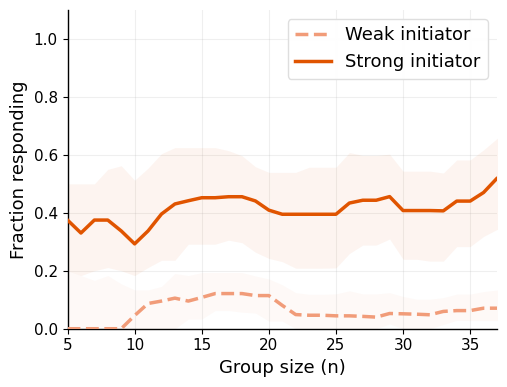

In [66]:
plot_DiTDeS_overlay(GMM_binary, ylim=(0, 1.1))


In [67]:
NoSpeedDecay.columns

Index(['Model', 'Area', 'Density', 'Include_Speed', 'Include_Density',
       'Include_Time', 'N_FRs', 'FR_speed', 'FR_speed_mode', 'FR_speed_label',
       'N_Fish', 'N_Startles', 'FR_LD_primary', 'FR_LD_percentile',
       'FR_LD_meanFR', 'FR_LD_z', 'Video_ID', 'Group_Size_Used',
       'Group_Size_Target', 'Group_Size_Requested', 'Error'],
      dtype='object')

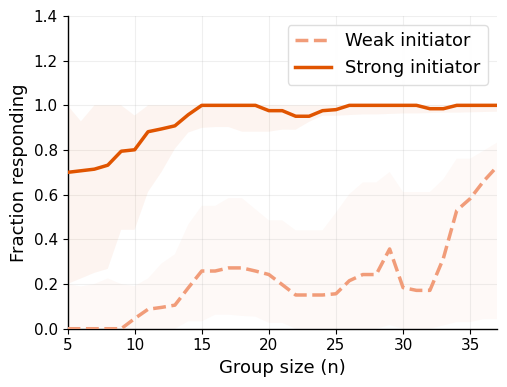

In [68]:
plot_DiTDeS_overlay(NoSpeedDecay, ylim=(0, 1.4))

In [69]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

DF = GMM_binary.copy()
DF["add_count"]  = DF["N_Startles"] - DF["N_FRs"]
DF["add_trials"] = DF["N_Fish"] - DF["N_FRs"]

# drop degenerate cases (no one to recruit)
DF = DF[DF["add_trials"] > 0].copy()

# weak/strong as categorical
DF["FR_speed_label"] = DF["FR_speed_label"].astype("category")

# Binomial GLM with counts via weights / endog as proportion
DF["add_prop"] = DF["add_count"] / DF["add_trials"]

m = smf.glm(
    "add_prop ~ FR_speed_label * N_Fish",
    data=DF,
    family=sm.families.Binomial(),
    freq_weights=DF["add_trials"]  # trials
).fit()

print(m.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               add_prop   No. Observations:                57600
Model:                            GLM   Df Residuals:                  1238396
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -7.0895e+05
Date:                Tue, 24 Feb 2026   Deviance:                   8.9767e+05
Time:                        13:46:20   Pearson chi2:                 7.30e+05
No. Iterations:                     4   Pseudo R-squ. (CS):             0.6309
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

### Q3: Why does a weak initiator fail to lead to spreading in small groups but sometimes leads to spreading in large groups?

In [70]:
df = Neighbour_Inputs_Summary.copy()

resp = df[df["responded"]].copy()

tab1 = (resp
    .groupby(["N_req", "FR_label"], dropna=False)
    .agg(
        mean_delta_at_startle=("input_delta_at_startle", "mean"),
        median_delta_at_startle=("input_delta_at_startle", "median"),
        frac_delta_pos=("input_delta_at_startle", lambda x: np.mean(x.fillna(0) > 1e-10)),
        n=("input_delta_at_startle", "size")
    )
    .reset_index()
    .sort_values(["N_req", "FR_label"])
)

tab1


,N_req,FR_label,mean_delta_at_startle,median_delta_at_startle,frac_delta_pos,n
0,8,strong,3.812139,0.000000,0.456580,1117
1,8,weak,0.338334,0.000000,0.234940,332
2,30,strong,5.651372,2.055516,0.749534,4292
3,30,weak,0.617582,0.000000,0.470085,819


In [71]:
# Keep only responders with an order
resp2 = resp.dropna(subset=["order_among_targets", "input_delta_at_startle"]).copy()
resp2["order_among_targets"] = resp2["order_among_targets"].astype(int)

tab2 = (resp2
    .groupby(["N_req", "FR_label", "order_among_targets"], dropna=False)
    .agg(
        mean_delta=("input_delta_at_startle", "mean"),
        median_delta=("input_delta_at_startle", "median"),
        n=("input_delta_at_startle", "size")
    )
    .reset_index()
    .sort_values(["N_req", "FR_label", "order_among_targets"])
)

tab2

,N_req,FR_label,order_among_targets,mean_delta,median_delta,n
0,8,strong,1,0.000000,0.000000,412
1,8,strong,2,4.790161,0.125890,318
2,8,strong,3,7.241225,2.403063,206
3,8,strong,4,7.124799,3.133343,112
4,8,strong,5,6.909532,2.570255,50
5,8,strong,6,4.409846,2.277051,17
6,8,strong,7,12.386790,12.386790,2
7,8,weak,1,0.000000,0.000000,221
8,8,weak,2,0.826706,0.109997,90
9,8,weak,3,2.015096,0.829780,16


In [72]:
non = df[~df["responded"]].copy()

tab3 = (non
    .groupby(["N_req", "FR_label"], dropna=False)
    .agg(
        mean_max_delta=("max_input_delta", "mean"),
        median_max_delta=("max_input_delta", "median"),
        frac_any_delta=("max_input_delta", lambda x: np.mean(x.fillna(0) > 1e-10)),
        n=("max_input_delta", "size")
    )
    .reset_index()
    .sort_values(["N_req", "FR_label"])
)

print(tab3)


   N_req FR_label  mean_max_delta  median_max_delta  frac_any_delta      n
0      8   strong        2.220688          0.921771        0.741502   2383
1      8     weak        0.291623          0.000000        0.383523   3168
2     30   strong        3.273008          1.819319        0.931818  10208
3     30     weak        0.376136          0.089798        0.650245  13681


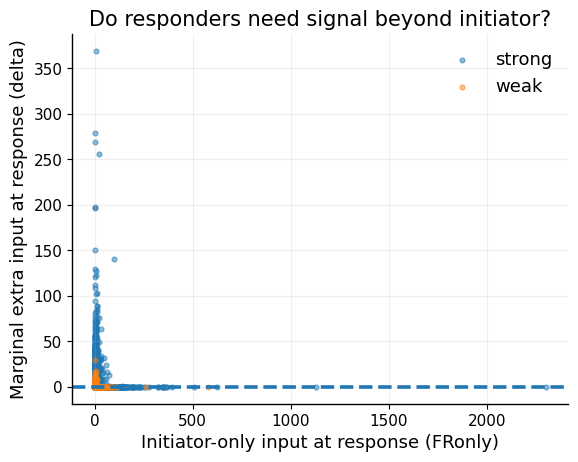

In [73]:
plt.figure()
sub = df.dropna(subset=["input_FRonly_at_startle", "input_delta_at_startle"]).copy()

# Only fish with a defined startle-time (responders)
sub = sub[sub["responded"]]

for lab in sorted(sub["FR_label"].unique()):
    s2 = sub[sub["FR_label"] == lab]
    plt.scatter(s2["input_FRonly_at_startle"], s2["input_delta_at_startle"], s=12, alpha=0.5, label=lab)

plt.axhline(0, linestyle="--")
plt.xlabel("Initiator-only input at response (FRonly)")
plt.ylabel("Marginal extra input at response (delta)")
plt.title("Do responders need signal beyond initiator?")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()


### Q4: In the real data: is the response speed of the initial responder dependent on group size? 

In [74]:
FR_Information['Speed'] = FR_Information["Speed"] / 1000  # convert ms to seconds if needed

model = smf.ols("Speed ~ Group_Size", data=FR_Information).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Speed   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     6.281
Date:                Tue, 24 Feb 2026   Prob (F-statistic):             0.0139
Time:                        13:46:20   Log-Likelihood:                -110.58
No. Observations:                  95   AIC:                             225.2
Df Residuals:                      93   BIC:                             230.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8853      0.155     12.184      0.0

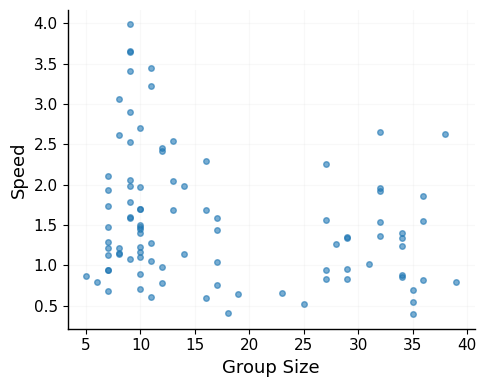

In [75]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(FR_Information["Group_Size"], FR_Information["Speed"], alpha=0.6)
ax.set_xlabel("Group Size")
ax.set_ylabel("Speed")
plt.tight_layout()
plt.show()

### Figure - Mechanism

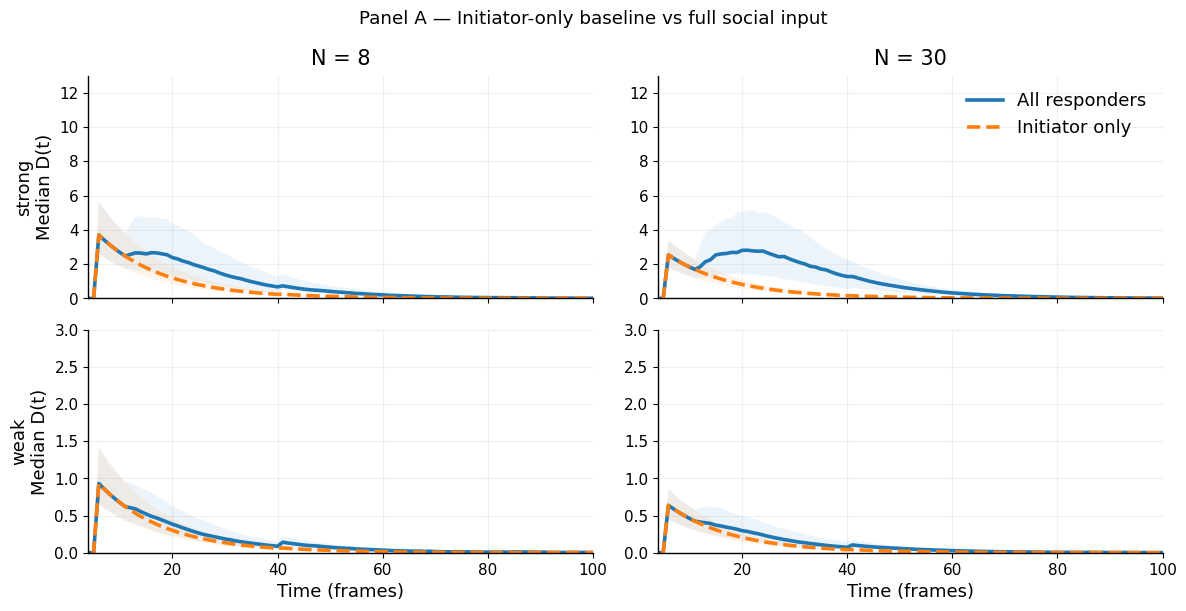

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# SETTINGS
# -------------------------
TRACE_PATH   = "PATH/TO/TRACE_ALL.csv"   # <- change
N_LIST       = [8, 30]
ROW_LABELS   = ["strong", "weak"]        # row 0, row 1
AREA_FOCUS   = None                      # e.g. 1.0 or None
T_MAX_PLOT   = 120                       # None for full
RIBBONS      = True                      # IQR ribbons
SMOOTH_W     = 1                         # 1=no smoothing; try 5 if jagged

# -------------------------
# LOAD + CLEAN
# -------------------------
tr = Neighbour_Inputs_Trace.copy()

for c in ["Rep_ID", "t", "N_req"]:
    tr[c] = pd.to_numeric(tr[c], errors="coerce")
for c in ["Input_D_all", "Input_D_FRonly"]:
    tr[c] = pd.to_numeric(tr[c], errors="coerce")

tr["FR_label"] = tr["FR_label"].astype(str)

# Optional filters
if AREA_FOCUS is not None and "Area" in tr.columns:
    tr = tr[tr["Area"] == AREA_FOCUS].copy()
if T_MAX_PLOT is not None:
    tr = tr[tr["t"] <= T_MAX_PLOT].copy()

tr = tr.dropna(subset=["Rep_ID", "t", "N_req", "FR_label", "Input_D_all", "Input_D_FRonly"])

# -------------------------
# Helper: robust summary for one (N_req, FR_label)
# 1) median across k targets within replicate+time
# 2) median + IQR across replicates
# -------------------------
def summarize_trace(df_sub):
    within_rep = (
        df_sub.groupby(["Rep_ID", "t"], as_index=False)
              .agg(D_all_med=("Input_D_all", "median"),
                   D_FR_med =("Input_D_FRonly", "median"))
    )

    def q(x, p):
        x = pd.Series(x).dropna()
        return np.nan if len(x) == 0 else float(np.quantile(x, p))

    summ = (
        within_rep.groupby("t", as_index=False)
                  .agg(
                      D_all=("D_all_med", "median"),
                      D_FR =("D_FR_med",  "median"),
                      D_all_q25=("D_all_med", lambda x: q(x, 0.25)),
                      D_all_q75=("D_all_med", lambda x: q(x, 0.75)),
                      D_FR_q25 =("D_FR_med",  lambda x: q(x, 0.25)),
                      D_FR_q75 =("D_FR_med",  lambda x: q(x, 0.75)),
                      n_reps=("t", "size")
                  )
    )


    # optional smoothing (rolling mean on time)
    if SMOOTH_W and SMOOTH_W > 1:
        summ = summ.sort_values("t")
        for col in ["D_all", "D_FR", "D_all_q25", "D_all_q75", "D_FR_q25", "D_FR_q75"]:
            summ[col] = summ[col].rolling(SMOOTH_W, center=True, min_periods=1).mean()

    return summ

# -------------------------
# BUILD FIGURE
# -------------------------
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12.0, 6.2),
    sharex=True
)

for r, fr_lab in enumerate(ROW_LABELS):
    for c, Nreq in enumerate(N_LIST):
        ax = axes[r, c]

        df_sub = tr[(tr["FR_label"] == fr_lab) & (tr["N_req"] == Nreq)].copy()

        if df_sub.empty:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            ax.set_axis_off()
            continue

        summ = summarize_trace(df_sub)

        # Lines
        ax.plot(summ["t"], summ["D_all"], label="All responders")
        ax.plot(summ["t"], summ["D_FR"], linestyle="--", label="Initiator only")

        # Ribbons (IQR)
        if RIBBONS:
            ax.fill_between(summ["t"], summ["D_all_q25"], summ["D_all_q75"], alpha=0.08)
            ax.fill_between(summ["t"], summ["D_FR_q25"],  summ["D_FR_q75"],  alpha=0.08)

        # Titles/labels
        if r == 0:
            ax.set_title(f"N = {Nreq}", pad=8)
        if c == 0:
            ax.set_ylabel(f"{fr_lab}\nMedian D(t)")
        else:
            ax.set_ylabel("")

        ax.grid(True, alpha=0.2)
        ax.set_xlim(4, 100)
        #ax.plot([40, 40], [0,16], color="red", linestyle=":", alpha=0.5, label="Stall Limit")

        # Only put legend once (top-right panel)
        if (r == 0) and (c == 1):
            ax.legend(frameon=False, loc="upper right")

# Shared x label for bottom row
for ax in axes[-1, :]:
    ax.set_xlabel("Time (frames)")
    ax.set_ylim(0, 3)

# Shares yaxis for top row
for ax in axes[0, :]:
    ax.set_ylim(0, 13)
    

fig.suptitle("Panel A — Initiator-only baseline vs full social input", y=0.98)
plt.tight_layout()
plt.show()


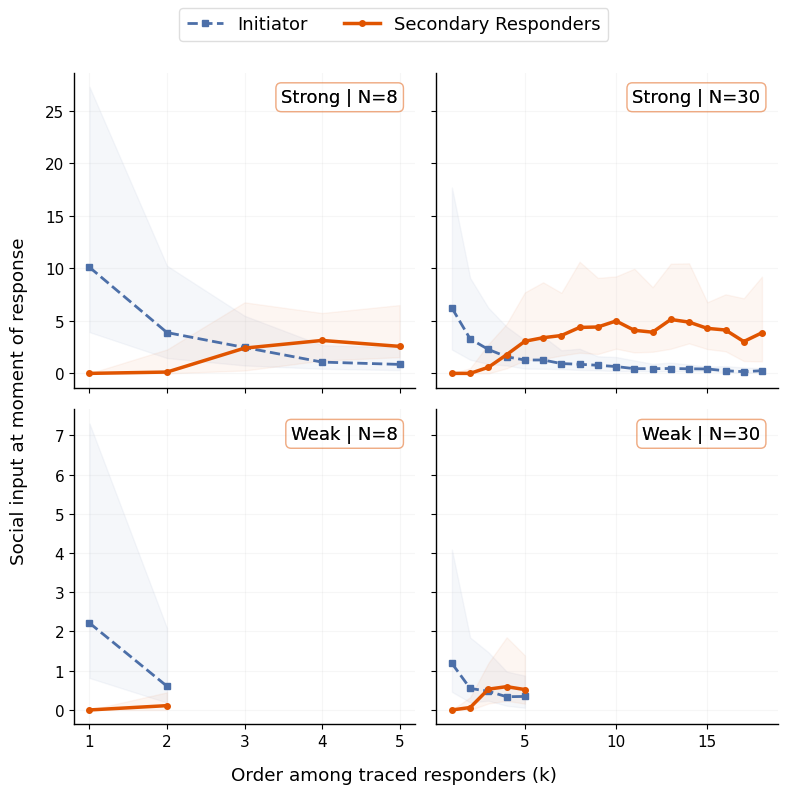

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# SETTINGS
# ----------------------------
N_LIST = [8, 30]
LABELS = ["strong", "weak"]

# Colors: SR = delta (secondary responders), FR = initiator-only baseline
COLORS = {
    "strong_SR": colors_figures_p2["Vermilion"],
    "weak_SR":   colors_figures_p2["Vermilion"],
    "strong_FR": "#4C6FA8",
    "weak_FR":   "#4C6FA8",
}

LINEWIDTHS = {
    "strong_SR": 2.5,
    "weak_SR": 2.5,
    "strong_FR": 2,
    "weak_FR": 2,
}

RIBBONS  = True
N_VALUES = False
TRUNCATE = True

SUPPORT_FRAC = 0.05
NSIMS = 500
N_MIN = int(np.ceil(SUPPORT_FRAC * NSIMS))

# ----------------------------
# LOAD
# ----------------------------
df = Neighbour_Inputs_Summary.copy()

# ----------------------------
# Identify the FR-only column (robust)
# ----------------------------
# common candidates we've seen in trace outputs
FR_CANDIDATES = [
    "input_FRonly_at_startle",
    "input_FR_only_at_startle",
    "input_fronly_at_startle",
    "input_fr_only_at_startle",
    "input_FR_at_startle",
    "input_fr_at_startle",
    "D_FRonly_at_startle",
    "D_FR_at_startle",
]

fr_col = None
for c in FR_CANDIDATES:
    if c in df.columns:
        fr_col = c
        break

# fallback: search by pattern
if fr_col is None:
    lower_cols = {c.lower(): c for c in df.columns}
    for key in lower_cols:
        if ("fr" in key) and ("startle" in key) and (("only" in key) or ("fronly" in key)):
            fr_col = lower_cols[key]
            break

if fr_col is None:
    raise ValueError(
        "Couldn't find the FR-only-at-startle column in Neighbour_Inputs_Summary.\n"
        "I expected something like one of:\n"
        f"  {FR_CANDIDATES}\n"
        "Columns I *do* see are:\n"
        f"  {list(df.columns)}"
    )

# ----------------------------
# CLEAN + FILTER
# ----------------------------
need_numeric = ["N_req", "order_among_targets", "input_delta_at_startle", fr_col]
for c in need_numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df[
    (df["responded"] == 1) &
    df["order_among_targets"].notna() &
    df["input_delta_at_startle"].notna() &
    df[fr_col].notna() &
    df["N_req"].notna()
].copy()

df["order_among_targets"] = df["order_among_targets"].astype(int)
df["N_req"] = df["N_req"].astype(int)

# ----------------------------
# LONG FORMAT: SR (delta) + FR (FR-only)
# ----------------------------
long = df.melt(
    id_vars=["N_req", "FR_label", "order_among_targets"],
    value_vars=["input_delta_at_startle", fr_col],
    var_name="metric",
    value_name="value"
)

metric_map = {
    "input_delta_at_startle": "SR",   # secondary responders (ΔD)
    fr_col: "FR"                      # initiator-only baseline
}
long["metric"] = long["metric"].map(metric_map)

# ----------------------------
# AGGREGATE: median + IQR + n
# ----------------------------
tab = (
    long.groupby(["N_req", "FR_label", "metric", "order_among_targets"], as_index=False)
        .agg(
            med=("value", "median"),
            q25=("value", lambda x: np.quantile(x, 0.25)),
            q75=("value", lambda x: np.quantile(x, 0.75)),
            n=("value", "size")
        )
)

# ----------------------------
# PLOT: rows = strength, cols = group size
# ----------------------------
fig, axes = plt.subplots(
    nrows=len(LABELS),
    ncols=len(N_LIST),
    figsize=(8, 8),
    sharey='row',
    sharex='col' # share x-axis between columns, but keep the limit of the top row (if different)
)

# ensure 2D array
if len(LABELS) == 1 and len(N_LIST) == 1:
    axes = np.array([[axes]])
elif len(LABELS) == 1:
    axes = np.array([axes])
elif len(N_LIST) == 1:
    axes = np.array([[ax] for ax in axes])

for r, lab in enumerate(LABELS):
    for c, Nreq in enumerate(N_LIST):
        ax = axes[r, c]
        ax.grid(True, alpha=0.1)

        for metric in ["FR", "SR"]:  # baseline first, delta second
            sub = tab[
                (tab["N_req"] == Nreq) &
                (tab["FR_label"] == lab) &
                (tab["metric"] == metric)
            ].copy().sort_values("order_among_targets")

            if sub.empty:
                continue

            if TRUNCATE:
                keep = sub["n"] >= N_MIN
                if keep.any():
                    last_ok_pos = np.where(keep.values)[0].max()
                    sub = sub.iloc[: last_ok_pos + 1].copy()
                else:
                    continue

            x = sub["order_among_targets"].to_numpy()
            y = sub["med"].to_numpy()

            color_key = f"{lab}_{metric}"

            # --- DIFFERENT LINE STYLES FOR B/W VISIBILITY ---
            if metric == "FR":
                linestyle = "--"        # dashed baseline
                marker = "s"            # square marker
                linewidth = 2.5
                zorder = 2
            else:
                linestyle = "-"         # solid for ΔD
                marker = "o"
                linewidth = 3
                zorder = 3

            ax.plot(
                x, y,
                linestyle=linestyle,
                marker=marker,
                linewidth=LINEWIDTHS[color_key],
                color=COLORS[color_key],
                zorder=zorder,
                label=("Initiator" if metric == "FR" else "Secondary Responders")
            )

            if RIBBONS:
                ax.fill_between(
                    x,
                    sub["q25"].to_numpy(),
                    sub["q75"].to_numpy(),
                    color=COLORS[color_key],
                    alpha=0.05
                )

            ax.text(
                0.95, 0.95, f"{lab.capitalize()} | N={Nreq}",
                ha="right", va="top",
                transform=ax.transAxes,
                fontsize=plt.rcParams["axes.titlesize"] - 2,
                bbox=dict(facecolor="white", alpha=0.3, edgecolor=colors_figures_p2["Vermilion"], pad=0.3, boxstyle="round")
            )


# ----------------------------
# Shared axis labels
# ----------------------------
fig.supxlabel("Order among traced responders (k)", y=0.02)
fig.supylabel("Social input at moment of response", x=0.02)


# single legend (clean)
handles, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="upper center", ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



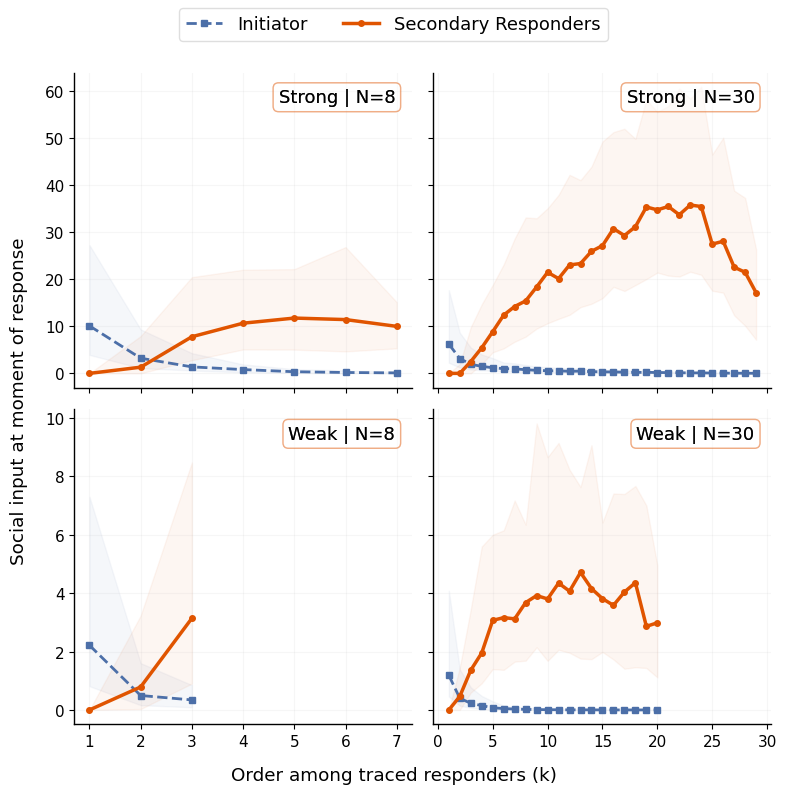

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# SETTINGS
# ----------------------------
N_LIST = [8, 30]
LABELS = ["strong", "weak"]

# Colors: SR = delta (secondary responders), FR = initiator-only baseline
COLORS = {
    "strong_SR": colors_figures_p2["Vermilion"],
    "weak_SR":   colors_figures_p2["Vermilion"],
    "strong_FR": "#4C6FA8",
    "weak_FR":   "#4C6FA8",
}

LINEWIDTHS = {
    "strong_SR": 2.5,
    "weak_SR": 2.5,
    "strong_FR": 2,
    "weak_FR": 2,
}

RIBBONS  = True
N_VALUES = False
TRUNCATE = True

SUPPORT_FRAC = 0.05
NSIMS = 500
N_MIN = int(np.ceil(SUPPORT_FRAC * NSIMS))

# ----------------------------
# LOAD
# ----------------------------
df = NSD_Neighbour_Inputs_Summary.copy()

# ----------------------------
# Identify the FR-only column (robust)
# ----------------------------
# common candidates we've seen in trace outputs
FR_CANDIDATES = [
    "input_FRonly_at_startle",
    "input_FR_only_at_startle",
    "input_fronly_at_startle",
    "input_fr_only_at_startle",
    "input_FR_at_startle",
    "input_fr_at_startle",
    "D_FRonly_at_startle",
    "D_FR_at_startle",
]

fr_col = None
for c in FR_CANDIDATES:
    if c in df.columns:
        fr_col = c
        break

# fallback: search by pattern
if fr_col is None:
    lower_cols = {c.lower(): c for c in df.columns}
    for key in lower_cols:
        if ("fr" in key) and ("startle" in key) and (("only" in key) or ("fronly" in key)):
            fr_col = lower_cols[key]
            break

if fr_col is None:
    raise ValueError(
        "Couldn't find the FR-only-at-startle column in Neighbour_Inputs_Summary.\n"
        "I expected something like one of:\n"
        f"  {FR_CANDIDATES}\n"
        "Columns I *do* see are:\n"
        f"  {list(df.columns)}"
    )

# ----------------------------
# CLEAN + FILTER
# ----------------------------
need_numeric = ["N_req", "order_among_targets", "input_delta_at_startle", fr_col]
for c in need_numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df[
    (df["responded"] == 1) &
    df["order_among_targets"].notna() &
    df["input_delta_at_startle"].notna() &
    df[fr_col].notna() &
    df["N_req"].notna()
].copy()

df["order_among_targets"] = df["order_among_targets"].astype(int)
df["N_req"] = df["N_req"].astype(int)

# ----------------------------
# LONG FORMAT: SR (delta) + FR (FR-only)
# ----------------------------
long = df.melt(
    id_vars=["N_req", "FR_label", "order_among_targets"],
    value_vars=["input_delta_at_startle", fr_col],
    var_name="metric",
    value_name="value"
)

metric_map = {
    "input_delta_at_startle": "SR",   # secondary responders (ΔD)
    fr_col: "FR"                      # initiator-only baseline
}
long["metric"] = long["metric"].map(metric_map)

# ----------------------------
# AGGREGATE: median + IQR + n
# ----------------------------
tab = (
    long.groupby(["N_req", "FR_label", "metric", "order_among_targets"], as_index=False)
        .agg(
            med=("value", "median"),
            q25=("value", lambda x: np.quantile(x, 0.25)),
            q75=("value", lambda x: np.quantile(x, 0.75)),
            n=("value", "size")
        )
)

# ----------------------------
# PLOT: rows = strength, cols = group size
# ----------------------------
fig, axes = plt.subplots(
    nrows=len(LABELS),
    ncols=len(N_LIST),
    figsize=(8, 8),
    sharey='row',
    sharex='col' # share x-axis between columns, but keep the limit of the top row (if different)
)

# ensure 2D array
if len(LABELS) == 1 and len(N_LIST) == 1:
    axes = np.array([[axes]])
elif len(LABELS) == 1:
    axes = np.array([axes])
elif len(N_LIST) == 1:
    axes = np.array([[ax] for ax in axes])

for r, lab in enumerate(LABELS):
    for c, Nreq in enumerate(N_LIST):
        ax = axes[r, c]
        ax.grid(True, alpha=0.1)

        for metric in ["FR", "SR"]:  # baseline first, delta second
            sub = tab[
                (tab["N_req"] == Nreq) &
                (tab["FR_label"] == lab) &
                (tab["metric"] == metric)
            ].copy().sort_values("order_among_targets")

            if sub.empty:
                continue

            if TRUNCATE:
                keep = sub["n"] >= N_MIN
                if keep.any():
                    last_ok_pos = np.where(keep.values)[0].max()
                    sub = sub.iloc[: last_ok_pos + 1].copy()
                else:
                    continue

            x = sub["order_among_targets"].to_numpy()
            y = sub["med"].to_numpy()

            color_key = f"{lab}_{metric}"

            # --- DIFFERENT LINE STYLES FOR B/W VISIBILITY ---
            if metric == "FR":
                linestyle = "--"        # dashed baseline
                marker = "s"            # square marker
                linewidth = 2.5
                zorder = 2
            else:
                linestyle = "-"         # solid for ΔD
                marker = "o"
                linewidth = 3
                zorder = 3

            ax.plot(
                x, y,
                linestyle=linestyle,
                marker=marker,
                linewidth=LINEWIDTHS[color_key],
                color=COLORS[color_key],
                zorder=zorder,
                label=("Initiator" if metric == "FR" else "Secondary Responders")
            )

            if RIBBONS:
                ax.fill_between(
                    x,
                    sub["q25"].to_numpy(),
                    sub["q75"].to_numpy(),
                    color=COLORS[color_key],
                    alpha=0.05
                )

            ax.text(
                0.95, 0.95, f"{lab.capitalize()} | N={Nreq}",
                ha="right", va="top",
                transform=ax.transAxes,
                fontsize=plt.rcParams["axes.titlesize"] - 2,
                bbox=dict(facecolor="white", alpha=0.3, edgecolor=colors_figures_p2["Vermilion"], pad=0.3, boxstyle="round")
            )


# ----------------------------
# Shared axis labels
# ----------------------------
fig.supxlabel("Order among traced responders (k)", y=0.02)
fig.supylabel("Social input at moment of response", x=0.02)


# single legend (clean)
handles, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="upper center", ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



In [79]:
import pandas as pd
import numpy as np

def responder_count_distribution_table(
    trace_df: pd.DataFrame,
    N_REPS: int,
    rep_col="Rep_ID",
    gs_col="N",
    fr_col="FR_label",
    order_col="order_among_targets",
    group_sizes=(8, 30),
    fr_labels=("weak", "strong"),
    decimals=1,
):
    """
    Returns a wide table:
      rows: k = EXACT number of non-FR responders (0 = only FR responds)
      cols: N8_strong, N8_weak, N30_strong, N30_weak
      values: percent of ALL simulation reps in that condition
    Columns will sum to ~100%.
    """

    df = trace_df.copy()
    df = df[df[gs_col].isin(group_sizes) & df[fr_col].isin(fr_labels)]

    # 1) For reps that appear in trace_df, k = max order
    per_rep = (
        df.groupby([gs_col, fr_col, rep_col], as_index=False)[order_col]
          .max()
          .rename(columns={order_col: "k"})
    )

    # 2) Create the FULL set of simulated reps per condition (Rep_ID = 1..N_REPS)
    all_runs = pd.DataFrame(
        [(N, fr, rep) for N in group_sizes for fr in fr_labels for rep in range(1, N_REPS + 1)],
        columns=[gs_col, fr_col, rep_col]
    )

    # 3) Merge: missing reps -> k = 0 (only FR responded)
    per_rep_full = all_runs.merge(per_rep, on=[gs_col, fr_col, rep_col], how="left")
    per_rep_full["k"] = per_rep_full["k"].fillna(0).astype(int)

    # 4) Exact-k distribution as percent of ALL reps
    dist = (
        per_rep_full.groupby([gs_col, fr_col, "k"])
                    .size()
                    .reset_index(name="n_exact")
    )
    dist["percent"] = dist["n_exact"] / N_REPS

    # 5) Wide layout
    wide = (
        dist.pivot_table(index="k", columns=[gs_col, fr_col], values="percent", fill_value=0)
            .sort_index(axis=1)
            .reset_index()
    )

    # Flatten columns
    wide.columns = ["k"] + [f"N{c[0]}_{c[1]}" for c in wide.columns[1:]]

    # Format percent
    out = wide.copy()
    out["k"] = out["k"].astype(int)
    for c in [c for c in out.columns if c != "k"]:
        out[c] = (out[c] * 100).round(decimals).astype(str) + "%"

    # Optional sanity check (prints sums ~100)
    sums = wide.drop(columns=["k"]).sum(axis=0) * 100

    return out, dist, per_rep_full


# ---- use it ----
pretty, dist, per_rep_full = responder_count_distribution_table(
    Neighbour_Inputs_Summary,
    N_REPS=500,  # <-- set this to your actual reps per condition
    order_col="order_among_targets"  # <-- make sure this matches your column name
)

pretty = pretty.reset_index(drop=True)
pretty


,k,N8_strong,N8_weak,N30_strong,N30_weak
0,0,17.6%,55.8%,4.8%,33.0%
1,1,18.8%,26.2%,5.4%,23.8%
2,2,22.4%,14.8%,5.0%,18.2%
3,3,18.8%,2.6%,4.8%,11.4%
4,4,12.4%,0.2%,6.8%,7.0%
5,5,6.6%,0.4%,7.0%,2.8%
6,6,3.0%,0.0%,5.6%,1.2%
7,7,0.4%,0.0%,5.6%,1.6%
8,8,0.0%,0.0%,7.0%,0.4%
9,9,0.0%,0.0%,6.2%,0.4%


In [80]:
import pandas as pd
import numpy as np

def responder_count_distribution_table(
    trace_df: pd.DataFrame,
    N_REPS: int,
    rep_col="Rep_ID",
    gs_col="N",
    fr_col="FR_label",
    order_col="order_among_targets",
    group_sizes=(8, 30),
    fr_labels=("weak", "strong"),
    decimals=1,
):
    """
    Returns a wide table:
      rows: k = EXACT number of non-FR responders (0 = only FR responds)
      cols: N8_strong, N8_weak, N30_strong, N30_weak
      values: percent of ALL simulation reps in that condition
    Columns will sum to ~100%.
    """

    df = trace_df.copy()
    df = df[df[gs_col].isin(group_sizes) & df[fr_col].isin(fr_labels)]

    # 1) For reps that appear in trace_df, k = max order
    per_rep = (
        df.groupby([gs_col, fr_col, rep_col], as_index=False)[order_col]
          .max()
          .rename(columns={order_col: "k"})
    )

    # 2) Create the FULL set of simulated reps per condition (Rep_ID = 1..N_REPS)
    all_runs = pd.DataFrame(
        [(N, fr, rep) for N in group_sizes for fr in fr_labels for rep in range(1, N_REPS + 1)],
        columns=[gs_col, fr_col, rep_col]
    )

    # 3) Merge: missing reps -> k = 0 (only FR responded)
    per_rep_full = all_runs.merge(per_rep, on=[gs_col, fr_col, rep_col], how="left")
    per_rep_full["k"] = per_rep_full["k"].fillna(0).astype(int)

    # 4) Exact-k distribution as percent of ALL reps
    dist = (
        per_rep_full.groupby([gs_col, fr_col, "k"])
                    .size()
                    .reset_index(name="n_exact")
    )
    dist["percent"] = dist["n_exact"] / N_REPS

    # 5) Wide layout
    wide = (
        dist.pivot_table(index="k", columns=[gs_col, fr_col], values="percent", fill_value=0)
            .sort_index(axis=1)
            .reset_index()
    )

    # Flatten columns
    wide.columns = ["k"] + [f"N{c[0]}_{c[1]}" for c in wide.columns[1:]]

    # Format percent
    out = wide.copy()
    out["k"] = out["k"].astype(int)
    for c in [c for c in out.columns if c != "k"]:
        out[c] = (out[c] * 100).round(decimals).astype(str) + "%"

    # Optional sanity check (prints sums ~100)
    sums = wide.drop(columns=["k"]).sum(axis=0) * 100

    return out, dist, per_rep_full


# ---- use it ----
pretty_NSD, dist_NSD, per_rep_full_NSD = responder_count_distribution_table(
    NSD_Neighbour_Inputs_Summary,
    N_REPS=500,  # <-- set this to your actual reps per condition
    order_col="order_among_targets"  # <-- make sure this matches your column name
)

pretty_NSD = pretty_NSD.reset_index(drop=True)
pretty_NSD


,k,N8_strong,N8_weak,N30_strong,N30_weak
0,0,17.6%,55.8%,4.8%,33.0%
1,1,7.8%,19.6%,1.2%,11.8%
2,2,8.2%,15.0%,0.2%,7.0%
3,3,9.0%,5.4%,0.0%,5.6%
4,4,11.6%,2.4%,0.0%,3.2%
5,5,14.8%,0.8%,0.0%,1.6%
6,6,19.0%,0.8%,0.0%,2.6%
7,7,12.0%,0.2%,0.0%,2.8%
8,8,0.0%,0.0%,0.0%,1.8%
9,9,0.0%,0.0%,0.0%,2.4%


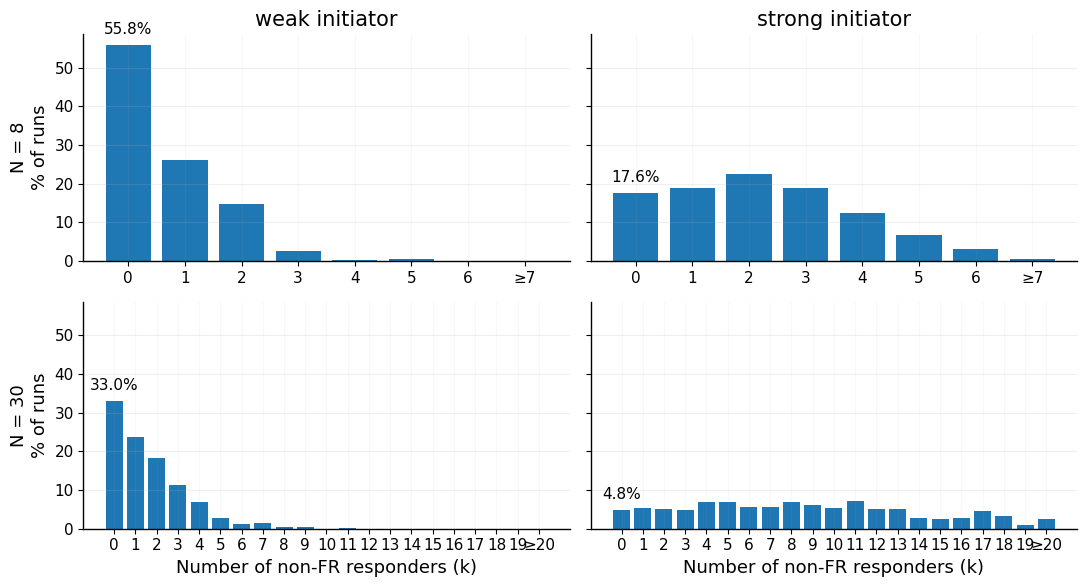

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_2x2_hist_k(per_rep_full,
                    Ns=(8, 30),
                    frs=("weak", "strong"),
                    Kcap_by_N={8: 6, 30: 8},
                    sharey=True):
    """
    2×2 histogram grid:
      rows = N (8,30)
      cols = FR_label (weak,strong)

    Truncates to bins 0..Kcap-1 plus a tail bin ≥Kcap.
    y = % of runs in that condition
    """

    fig, axes = plt.subplots(len(Ns), len(frs), figsize=(11, 6), sharey=sharey)

    for i, N in enumerate(Ns):
        for j, fr in enumerate(frs):
            ax = axes[i, j] if len(Ns) > 1 else axes[j]

            Kcap = Kcap_by_N.get(N, 8)
            sub = per_rep_full[(per_rep_full["N"] == N) & (per_rep_full["FR_label"] == fr)].copy()

            # Bin k into 0..Kcap-1 and tail bin at Kcap
            sub["k_bin"] = np.where(sub["k"] >= Kcap, Kcap, sub["k"]).astype(int)

            # Count and convert to %
            tab = sub["k_bin"].value_counts().sort_index()
            # Ensure missing bins are present
            bins = list(range(0, Kcap)) + [Kcap]
            tab = tab.reindex(bins, fill_value=0)
            pct = tab / tab.sum() * 100

            # Plot
            x = np.arange(len(bins))
            labels = [str(b) for b in range(0, Kcap)] + [f"≥{Kcap}"]
            ax.bar(x, pct.values)

            ax.set_xticks(x)
            ax.set_xticklabels(labels)
            ax.grid(alpha=0.2, axis="y")

            if i == 0:
                ax.set_title(f"{fr} initiator")
            if j == 0:
                ax.set_ylabel(f"N = {N}\n% of runs")
            if i == len(Ns) - 1:
                ax.set_xlabel("Number of non-FR responders (k)")

            # Optional: make k=0 pop with annotation
            ax.annotate(f"{pct.iloc[0]:.1f}%",
                        xy=(0, pct.iloc[0]),
                        xytext=(0, pct.iloc[0] + 2),
                        ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

# Example:
plot_2x2_hist_k(per_rep_full, Kcap_by_N={8:7, 30:20})


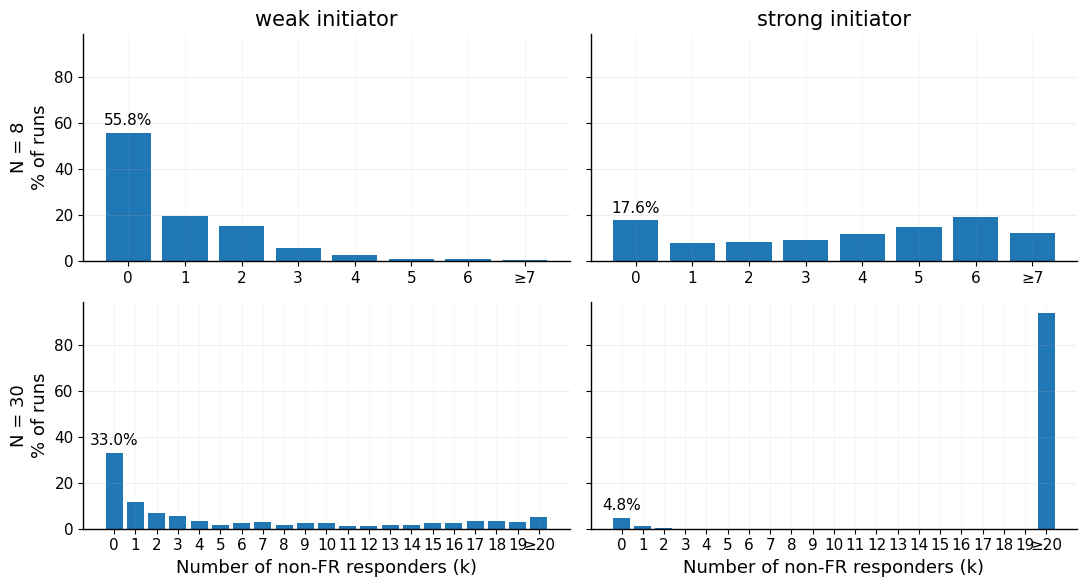

In [82]:
plot_2x2_hist_k(per_rep_full_NSD, Kcap_by_N={8:7, 30:20})

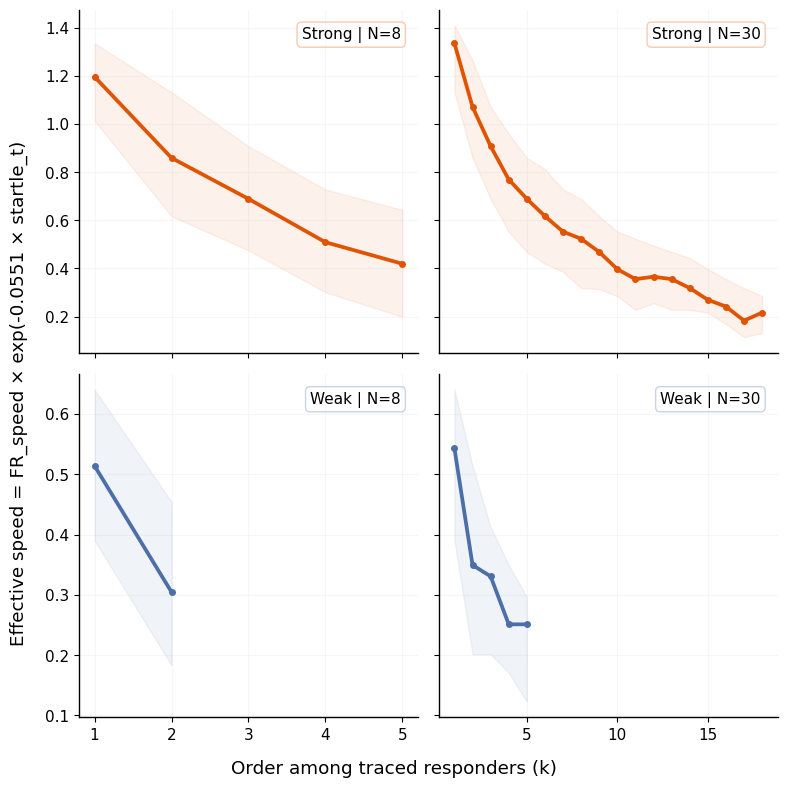

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# SETTINGS
# ----------------------------
N_LIST = [8, 30]
LABELS = ["strong", "weak"]

RIBBONS       = True
TRUNCATE_TAIL = True

SUPPORT_FRAC = 0.05
NSIMS        = 500
N_MIN        = int(np.ceil(SUPPORT_FRAC * NSIMS))

COLORS = {
    "strong": colors_figures_p2["Vermilion"],
    "weak":   "#4C6FA8",
}

SPEED_DECAY = 0.0551  # <-- your fitted parameter (per frame, if startle_t is frames)

# ----------------------------
# LOAD
# ----------------------------
df = Neighbour_Inputs_Summary.copy()

# ----------------------------
# Find needed columns
# ----------------------------
FR_SPEED_CANDIDATES = ["FR_speed", "fr_speed", "FR_Speed", "initiator_speed", "FR_v"]
T_CANDIDATES = ["startle_t", "t_startle", "t_response", "startle_time", "response_time"]

def find_col(cands):
    for c in cands:
        if c in df.columns:
            return c
    lower = {c.lower(): c for c in df.columns}
    for c in cands:
        if c.lower() in lower:
            return lower[c.lower()]
    return None

fr_speed_col = find_col(FR_SPEED_CANDIDATES)
t_col        = find_col(T_CANDIDATES)

if fr_speed_col is None:
    raise ValueError(f"Couldn't find FR speed column. Tried: {FR_SPEED_CANDIDATES}\nCols: {list(df.columns)}")
if t_col is None:
    raise ValueError(f"Couldn't find startle time column. Tried: {T_CANDIDATES}\nCols: {list(df.columns)}")

# ----------------------------
# CLEAN + FILTER
# ----------------------------
for c in ["N_req", "order_among_targets", fr_speed_col, t_col]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df[
    (df["responded"] == 1) &
    df["N_req"].notna() &
    df["order_among_targets"].notna() &
    df[fr_speed_col].notna() &
    df[t_col].notna()
].copy()

df["N_req"] = df["N_req"].astype(int)
df["order_among_targets"] = df["order_among_targets"].astype(int)

# ----------------------------
# EFFECTIVE SPEED YOU WANT
# v_eff = FR_speed * exp(-speed_decay * startle_t)
# ----------------------------
df["v_eff"] = df[fr_speed_col] * np.exp(-SPEED_DECAY * df[t_col])

# ----------------------------
# AGGREGATE: median + IQR + n
# ----------------------------
tab_v = (
    df.groupby(["N_req", "FR_label", "order_among_targets"], as_index=False)
      .agg(
          med=("v_eff", "median"),
          q25=("v_eff", lambda x: np.quantile(x, 0.25)),
          q75=("v_eff", lambda x: np.quantile(x, 0.75)),
          n=("v_eff", "size")
      )
)

# ----------------------------
# PLOT: rows = strength, cols = group size
# ----------------------------
fig, axes = plt.subplots(
    nrows=len(LABELS),
    ncols=len(N_LIST),
    figsize=(8, 8),
    sharey="row",
    sharex="col",
)

# ensure 2D array
if len(LABELS) == 1 and len(N_LIST) == 1:
    axes = np.array([[axes]])
elif len(LABELS) == 1:
    axes = np.array([axes])
elif len(N_LIST) == 1:
    axes = np.array([[ax] for ax in axes])

for r, lab in enumerate(LABELS):
    for c, Nreq in enumerate(N_LIST):
        ax = axes[r, c]
        ax.grid(True, alpha=0.1)

        sub = tab_v[
            (tab_v["N_req"] == Nreq) &
            (tab_v["FR_label"] == lab)
        ].sort_values("order_among_targets").copy()

        if sub.empty:
            continue

        keep = sub["n"] >= N_MIN
        if not keep.any():
            ax.text(0.5, 0.5, "No orders pass support",
                    ha="center", va="center", transform=ax.transAxes)
            continue

        if TRUNCATE_TAIL:
            last_ok = np.where(keep.values)[0].max()
            sub = sub.iloc[: last_ok + 1].copy()
        else:
            sub = sub.loc[keep].copy()

        x = sub["order_among_targets"].to_numpy()
        y = sub["med"].to_numpy()

        ax.plot(x, y, marker="o", linewidth=2.7, color=COLORS[lab])

        if RIBBONS:
            ax.fill_between(
                x,
                sub["q25"].to_numpy(),
                sub["q75"].to_numpy(),
                color=COLORS[lab],
                alpha=0.08
            )

        ax.text(
            0.95, 0.95, f"{lab.capitalize()} | N={Nreq}",
            ha="right", va="top",
            transform=ax.transAxes,
            bbox=dict(facecolor="white", alpha=0.3, edgecolor=COLORS[lab],
                      pad=0.3, boxstyle="round")
        )

fig.supxlabel("Order among traced responders (k)", y=0.02)
fig.supylabel(
    f"Effective speed = {fr_speed_col} × exp(-{SPEED_DECAY} × {t_col})",
    x=0.02
)

plt.tight_layout()
plt.show()


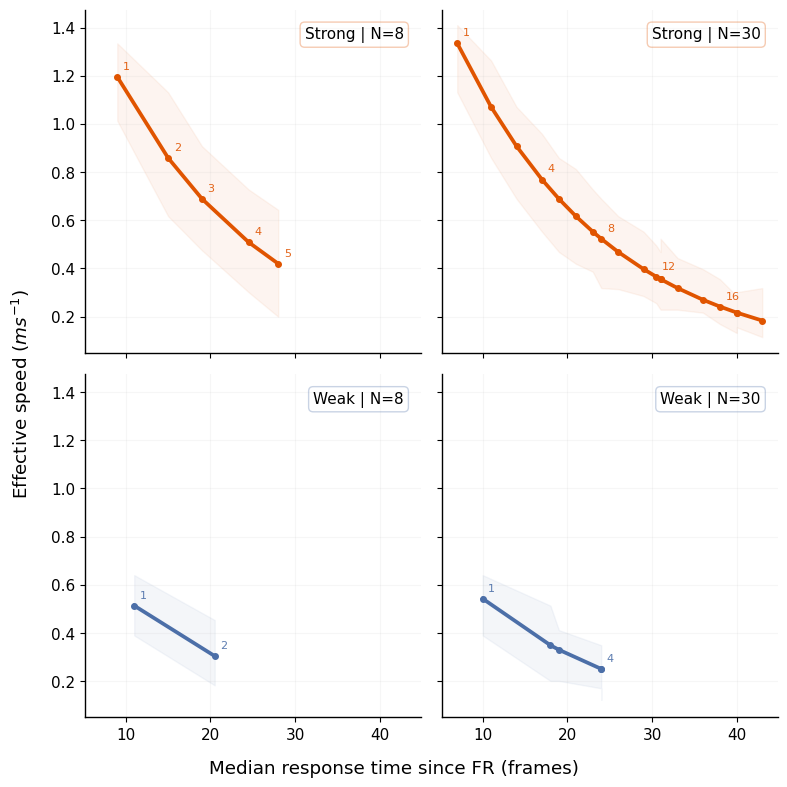

In [84]:
# ----------------------------
# AGGREGATE: median time + median v_eff + IQR + n
# ----------------------------
tab_v = (
    df.groupby(["N_req", "FR_label", "order_among_targets"], as_index=False)
      .agg(
          t_med=(t_col, "median"),             # <-- median startle time
          med=("v_eff", "median"),
          q25=("v_eff", lambda x: np.quantile(x, 0.25)),
          q75=("v_eff", lambda x: np.quantile(x, 0.75)),
          n=("v_eff", "size")
      )
)

# ----------------------------
# PLOT: rows = strength, cols = group size
# ----------------------------
fig, axes = plt.subplots(
    nrows=len(LABELS),
    ncols=len(N_LIST),
    figsize=(8, 8),
    sharey="all",
    sharex='all',   # time differs across N
)

# ensure 2D array
if len(LABELS) == 1 and len(N_LIST) == 1:
    axes = np.array([[axes]])
elif len(LABELS) == 1:
    axes = np.array([axes])
elif len(N_LIST) == 1:
    axes = np.array([[ax] for ax in axes])

for r, lab in enumerate(LABELS):
    for c, Nreq in enumerate(N_LIST):
        ax = axes[r, c]
        ax.grid(True, alpha=0.1)

        sub = tab_v[
            (tab_v["N_req"] == Nreq) &
            (tab_v["FR_label"] == lab)
        ].sort_values("t_med").copy()   # sort by time now

        if sub.empty:
            continue

        keep = sub["n"] >= N_MIN
        if not keep.any():
            ax.text(0.5, 0.5, "No orders pass support",
                    ha="center", va="center", transform=ax.transAxes)
            continue

        if TRUNCATE_TAIL:
            last_ok = np.where(keep.values)[0].max()
            sub = sub.iloc[: last_ok + 1].copy()
        else:
            sub = sub.loc[keep].copy()

        # ----------------------------
        # x = median startle time
        # ----------------------------
        x = sub["t_med"].to_numpy()
        y = sub["med"].to_numpy()

        ax.plot(x, y, marker="o", linewidth=2.7, color=COLORS[lab])

        # --- label markers with order k (sparsify for big panels) ---
        k_vals = sub["order_among_targets"].to_numpy()
        x_vals = sub["t_med"].to_numpy()
        y_vals = sub["med"].to_numpy()

        # label all in small-N; every 5th in large-N
        if Nreq <= 10:
            label_mask = np.ones_like(k_vals, dtype=bool)
        else:
            label_mask = (k_vals == 1) | (k_vals % 4 == 0)

        for kk, xx, yy, ok in zip(k_vals, x_vals, y_vals, label_mask):
            if not ok:
                continue
            ax.annotate(
                str(int(kk)),
                (xx, yy),
                textcoords="offset points",
                xytext=(4, 4),
                ha="left",
                va="bottom",
                fontsize=8,
                color=COLORS[lab],
                alpha=0.9
            )


        if RIBBONS:
            ax.fill_between(
                x,
                sub["q25"].to_numpy(),
                sub["q75"].to_numpy(),
                color=COLORS[lab],
                alpha=0.06
            )

        ax.text(
            0.95, 0.95, f"{lab.capitalize()} | N={Nreq}",
            ha="right", va="top",
            transform=ax.transAxes,
            bbox=dict(facecolor="white", alpha=0.3,
                      edgecolor=COLORS[lab],
                      pad=0.3, boxstyle="round")
        )

fig.supxlabel("Median response time since FR (frames)", y=0.02)
fig.supylabel(
    r"Effective speed ($m s^{-1}$)",
    x=0.02
)

plt.tight_layout()
plt.show()
